In [7]:
import re
import cv2
import numpy as np
from pathlib import Path
from docx import Document
from paddleocr import PaddleOCR , draw_ocr
from docx.enum.text import WD_ALIGN_PARAGRAPH
from docx.oxml import OxmlElement
from docx.oxml.ns import qn
import arabic_reshaper
from hazm import Normalizer
from bidi.algorithm import get_display

In [8]:
import cv2


def load_image(image_path):
    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(image_path)

    return image


def crop_roi(image, field_config):

    h, w = image.shape[:2]

    roi = field_config["roi"]

    margin = field_config.get("margin", 0)

    y1 = int(roi[0] * h)
    y2 = int(roi[1] * h)

    x1 = int(roi[2] * w)
    x2 = int(roi[3] * w)

    y1 = max(0, y1 - margin)
    x1 = max(0, x1 - margin)

    y2 = min(h, y2 + margin)
    x2 = min(w, x2 + margin)

    return image[y1:y2, x1:x2]

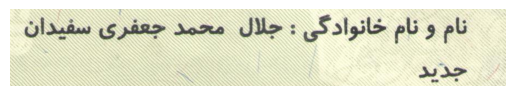

In [9]:


from config import CONFIG





image = load_image('test_002.jpg')

crop = crop_roi(image, CONFIG["name"])

crop2 = crop_roi(image, CONFIG["VIN"])
import matplotlib.pyplot as plt
import cv2



plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

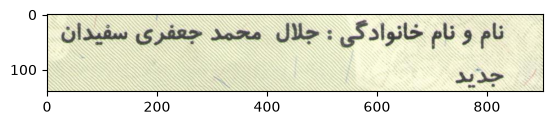

In [10]:
cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
cv2.waitKey(0)
cv2.destroyAllWindows()
plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))

In [11]:
gray = cv2.cvtColor(crop,cv2.COLOR_BGR2GRAY)

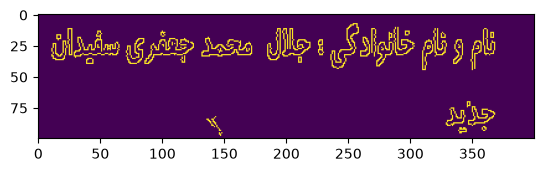

In [13]:

resized = cv2.resize(gray, (400, 100))

edges = cv2.Canny(resized, 300, 100)
plt.imshow(edges)

In [23]:
ocr_fa = PaddleOCR( 
    lang="fa"
)

In [ ]:
result= ocr_fa.ocr(gray)

texts = [line[1][0] for line in result[0]]

#reshaped_text = arabic_reshaper.reshape(texts)
#final=get_display(reshaped_text)
#print(final)
#correct_text = texts[::-1]
#print(reshaped_text)
from bidi.algorithm import get_display
import arabic_reshaper

normalizer = Normalizer()

def fix_display(text):
    s=[]
    
    for Text in text:
        normalized = normalizer.normalize(Text)
        reshaped = arabic_reshaper.reshape(normalized)
        s.append(get_display(reshaped))
    return s




[2026/08/02 08:11:28] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process


['ناديفس', 'لالج', 'ىكداوناخ', 'ماان', 'ىرفعج', ' مان', ' لمحم', 'ديدج']

In [32]:
from paddleocr import PaddleOCR
#ورودی
#processed_crop
#language

#خروجی
#raw_text

#confidence

#مثلاً

#text, conf = run_ocr(crop,"fa")


from paddleocr import PaddleOCR


class OCREngine:

    def __init__(self):
        self.engines = {
            "fa": PaddleOCR(
                use_angle_cls=True,
                lang="fa",
                show_log=False
            ),

            "en": PaddleOCR(
                use_angle_cls=True,
                lang="en",
                show_log=False
            )
        }

    def recognize(self, crop, field_config):

        lang = field_config["lang"]

        engine = self.engines[lang]

        result = engine.ocr(crop, cls=True)

        texts = []
        boxes = []
        confidences = []

        if result and result[0]:
            for item in result[0]:
                boxes.append(item[0])
                texts.append(item[1][0])
                confidences.append(item[1][1])

        return {
            "texts": texts,
            "boxes": boxes,
            "confidences": confidences
        }


In [35]:
ocr=OCREngine()
ocr_result = ocr.recognize(crop, 'fa')

raw_text = sort_lines(

    texts=ocr_result["texts"],
    boxes=ocr_result["boxes"],
    rtl=(field_config["lang"] == "fa"))

TypeError: string indices must be integers, not 'str'

In [28]:
"""
normalize.py

توابع نرمال‌سازی خروجی OCR
"""

import re

# ---------------------------------------------------------
# تبدیل کاراکترهای Presentation Forms به حروف استاندارد فارسی
# ---------------------------------------------------------

PRESENTATION_FORMS_MAP = {
    'ﺁ': 'آ', 'ﺂ': 'آ', 'ﺃ': 'أ', 'ﺄ': 'أ', 'ﺇ': 'إ', 'ﺈ': 'إ',
    'ﺍ': 'ا', 'ﺎ': 'ا', 'ﺏ': 'ب', 'ﺐ': 'ب', 'ﺑ': 'ب', 'ﺒ': 'ب',
    'ﭖ': 'پ', 'ﭗ': 'پ', 'ﭘ': 'پ', 'ﭙ': 'پ',
    'ﺕ': 'ت', 'ﺖ': 'ت', 'ﺗ': 'ت', 'ﺘ': 'ت',
    'ﺙ': 'ث', 'ﺚ': 'ث', 'ﺛ': 'ث', 'ﺜ': 'ث',
    'ﺝ': 'ج', 'ﺞ': 'ج', 'ﺟ': 'ج', 'ﺠ': 'ج',
    'ﭺ': 'چ', 'ﭻ': 'چ', 'ﭼ': 'چ', 'ﭽ': 'چ',
    'ﺡ': 'ح', 'ﺢ': 'ح', 'ﺣ': 'ح', 'ﺤ': 'ح',
    'ﺥ': 'خ', 'ﺦ': 'خ', 'ﺧ': 'خ', 'ﺨ': 'خ',
    'ﺩ': 'د', 'ﺪ': 'د',
    'ﺫ': 'ذ', 'ﺬ': 'ذ',
    'ﺭ': 'ر', 'ﺮ': 'ر',
    'ﺯ': 'ز', 'ﺰ': 'ز',
    'ﮊ': 'ژ', 'ﮋ': 'ژ',
    'ﺱ': 'س', 'ﺲ': 'س', 'ﺳ': 'س', 'ﺴ': 'س',
    'ﺵ': 'ش', 'ﺶ': 'ش', 'ﺷ': 'ش', 'ﺸ': 'ش',
    'ﺹ': 'ص', 'ﺺ': 'ص', 'ﺻ': 'ص', 'ﺼ': 'ص',
    'ﺽ': 'ض', 'ﺾ': 'ض', 'ﺿ': 'ض', 'ﻀ': 'ض',
    'ﻁ': 'ط', 'ﻂ': 'ط', 'ﻃ': 'ط', 'ﻄ': 'ط',
    'ﻅ': 'ظ', 'ﻆ': 'ظ', 'ﻇ': 'ظ', 'ﻈ': 'ظ',
    'ﻉ': 'ع', 'ﻊ': 'ع', 'ﻋ': 'ع', 'ﻌ': 'ع',
    'ﻍ': 'غ', 'ﻎ': 'غ', 'ﻏ': 'غ', 'ﻐ': 'غ',
    'ﻑ': 'ف', 'ﻒ': 'ف', 'ﻓ': 'ف', 'ﻔ': 'ف',
    'ﻕ': 'ق', 'ﻖ': 'ق', 'ﻗ': 'ق', 'ﻘ': 'ق',
    'ﻙ': 'ک', 'ﻚ': 'ک', 'ﻛ': 'ک', 'ﻜ': 'ک',
    'ﮎ': 'ک', 'ﮏ': 'ک', 'ﮐ': 'ک', 'ﮑ': 'ک',
    'ﮒ': 'گ', 'ﮓ': 'گ', 'ﮔ': 'گ', 'ﮕ': 'گ',
    'ﻝ': 'ل', 'ﻞ': 'ل', 'ﻟ': 'ل', 'ﻠ': 'ل',
    'ﻡ': 'م', 'ﻢ': 'م', 'ﻣ': 'م', 'ﻤ': 'م',
    'ﻥ': 'ن', 'ﻦ': 'ن', 'ﻧ': 'ن', 'ﻨ': 'ن',
    'ﻭ': 'و', 'ﻮ': 'و',
    'ﻩ': 'ه', 'ﻪ': 'ه', 'ﻫ': 'ه', 'ﻬ': 'ه',
    'ﯼ': 'ی', 'ﯽ': 'ی', 'ﯾ': 'ی', 'ﯿ': 'ی',
    'ﻱ': 'ی', 'ﻲ': 'ی', 'ﻳ': 'ی', 'ﻴ': 'ی',
    'ﺋ': 'ئ', 'ﺌ': 'ئ',
    'ﺀ': 'ء'
}


# ---------------------------------------------------------
# نرمال سازی کاراکترها
# ---------------------------------------------------------

def normalize_characters(text: str) -> str:

    if not text:
        return ""

    return "".join(
        PRESENTATION_FORMS_MAP.get(ch, ch)
        for ch in text
    )


# ---------------------------------------------------------
# حذف فاصله های اضافی
# ---------------------------------------------------------

def normalize_spaces(text: str) -> str:

    if not text:
        return ""

    text = re.sub(r"\s+", " ", text)

    return text.strip()


# ---------------------------------------------------------
# تبدیل ارقام فارسی و عربی به انگلیسی
# ---------------------------------------------------------

def normalize_digits(text: str) -> str:

    if not text:
        return ""

    digit_map = str.maketrans({

        "۰":"0",
        "۱":"1",
        "۲":"2",
        "۳":"3",
        "۴":"4",
        "۵":"5",
        "۶":"6",
        "۷":"7",
        "۸":"8",
        "۹":"9",

        "٠":"0",
        "١":"1",
        "٢":"2",
        "٣":"3",
        "٤":"4",
        "٥":"5",
        "٦":"6",
        "٧":"7",
        "٨":"8",
        "٩":"9",

    })

    return text.translate(digit_map)


# ---------------------------------------------------------
# برعکس کردن متن فارسی
# ---------------------------------------------------------

def reverse_text(text: str, lang: str) -> str:

    if lang == "fa":

        return text[::-1]

    return text


# ---------------------------------------------------------
# حذف نویزهای متداول OCR
# ---------------------------------------------------------

def remove_noise(text: str) -> str:

    if not text:
        return ""

    text = text.replace("،", " ")
    text = text.replace(";", " ")
    text = text.replace("؛", " ")
    text = text.replace("|", " ")
    text = text.replace("_", " ")

    return normalize_spaces(text)


# ---------------------------------------------------------
# تابع اصلی نرمال سازی
# ---------------------------------------------------------

def normalize_text(text: str, lang: str) -> str:

    text = normalize_characters(text)

    text = normalize_digits(text)

    text = normalize_spaces(text)

    text = reverse_text(text, lang)

    text = remove_noise(text)

    return text

x=normalize_text(texts,'fa')
x

'حذيرمحمدنام وفام خانوادكى :جالالجعفرىسفيدان'

In [26]:

result= ocr_fa.ocr(edges)

texts = [line[1][0] for line in result[0]]
texts

[2026/08/02 08:13:30] ppocr WARNING: Since the angle classifier is not initialized, it will not be used during the forward process


['ناديفس', 'ىرفعج', 'لالاج: ىكداوناخ مافو مان', 'دمحم', 'ريذح']

In [11]:
from PIL import Image

In [16]:
img = Image.open('test_002.jpg')

In [17]:
img.show()

In [18]:
from PIL import ImageEnhance

In [26]:
enhancer = ImageEnhance.Contrast(img)



img.show()